##Install Library

In [ ]:
!pip install transformers scikit-learn pandas numpy torch tqdm seaborn -q

##Import Library

In [ ]:
import pandas as pd
import numpy as np
import re
import torch

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import AutoTokenizer, AutoModel

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

##Upload dan Load Data

In [ ]:
uploaded = files.upload()
nama_file = list(uploaded.keys())[0]

df = pd.read_csv(nama_file, sep=";", dtype=str)

print("Data berhasil diload")
print("Nama file:", nama_file)
print("Jumlah baris:", len(df))
print("Jumlah kolom:", len(df.columns))
print("Kolom:", df.columns.tolist())

display(df.head())

Saving Data_Siap_Tanpa_Emoticon.csv to Data_Siap_Tanpa_Emoticon.csv
Data berhasil diload
Nama file: Data_Siap_Tanpa_Emoticon.csv
Jumlah baris: 1215
Jumlah kolom: 5
Kolom: ['No', 'cleaning', 'label', 'dimensi_MBI', 'catatan']


,No,cleaning,label,dimensi_MBI,catatan
0,1,ternyata bukam capek kerja tapi capek sama kea...,burnout,EE,-
1,2,capek capek kerja nabung duitnya dipinjem oran...,burnout,EE,-
2,3,capek kerja lembur sampe jam kmaren langsung l...,tidak_burnout,tidak_burnout,-
3,4,pertanyaan teh ica saat ketemu di sydney adala...,tidak_burnout,tidak_burnout,-
4,5,gw lg di tahap capek kerja dg lingkungan kerja...,burnout,EE,-


##Cek Kolom

In [ ]:
kolom_wajib = ["cleaning", "label", "dimensi_MBI"]

for kolom in kolom_wajib:
    if kolom not in df.columns:
        raise ValueError(f"Kolom '{kolom}' tidak ditemukan. Kolom tersedia: {df.columns.tolist()}")

print("Semua kolom wajib ditemukan.")

Semua kolom wajib ditemukan.


## Preprocessing Final Indobert

In [ ]:
def preprocessing_final(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # hapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # hapus mention username
    text = re.sub(r"@\w+", " ", text)

    # hapus simbol hashtag, kata tetap dipertahankan
    text = re.sub(r"#", "", text)

    # hapus karakter selain huruf, angka, dan spasi
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # rapikan spasi
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["teks_final"] = df["cleaning"].apply(preprocessing_final)

# hapus teks kosong
df = df[df["teks_final"].str.strip() != ""].reset_index(drop=True)

print("Jumlah data setelah preprocessing final:", len(df))
display(df[["cleaning", "teks_final", "label", "dimensi_MBI"]].head(10))

Jumlah data setelah preprocessing final: 1215


,cleaning,teks_final,label,dimensi_MBI
0,ternyata bukam capek kerja tapi capek sama kea...,ternyata bukam capek kerja tapi capek sama kea...,burnout,EE
1,capek capek kerja nabung duitnya dipinjem oran...,capek capek kerja nabung duitnya dipinjem oran...,burnout,EE
2,capek kerja lembur sampe jam kmaren langsung l...,capek kerja lembur sampe jam kmaren langsung l...,tidak_burnout,tidak_burnout
3,pertanyaan teh ica saat ketemu di sydney adala...,pertanyaan teh ica saat ketemu di sydney adala...,tidak_burnout,tidak_burnout
4,gw lg di tahap capek kerja dg lingkungan kerja...,gw lg di tahap capek kerja dg lingkungan kerja...,burnout,EE
5,jungkook dah capek kerja tahun jadi mau istira...,jungkook dah capek kerja tahun jadi mau istira...,tidak_burnout,tidak_burnout
6,apapun ya kudu dilakoni karna capek kerja akan...,apapun ya kudu dilakoni karna capek kerja akan...,tidak_burnout,tidak_burnout
7,buat kalian yang udah kerja gua doain semoga s...,buat kalian yang udah kerja gua doain semoga s...,tidak_burnout,tidak_burnout
8,sebenernya capek kerja sama dengan orangorang ...,sebenernya capek kerja sama dengan orangorang ...,burnout,CY
9,memasuki fase bukan capek kerja tapi masuk ke ...,memasuki fase bukan capek kerja tapi masuk ke ...,burnout,EE


##Clean dan Encode Label

In [ ]:
df["label"] = df["label"].str.strip().str.lower()

df = df[df["label"].isin(["burnout", "tidak_burnout"])].reset_index(drop=True)

label2id = {
    "tidak_burnout": 0,
    "burnout": 1
}

id2label = {
    0: "tidak_burnout",
    1: "burnout"
}

df["labels"] = df["label"].map(label2id)

print("Jumlah data valid:", len(df))

print("\nDistribusi label:")
print(df["label"].value_counts())

display(df[["teks_final", "label", "labels", "dimensi_MBI"]].head())

Jumlah data valid: 1215

Distribusi label:
label
burnout          740
tidak_burnout    475
Name: count, dtype: int64


,teks_final,label,labels,dimensi_MBI
0,ternyata bukam capek kerja tapi capek sama kea...,burnout,1,EE
1,capek capek kerja nabung duitnya dipinjem oran...,burnout,1,EE
2,capek kerja lembur sampe jam kmaren langsung l...,tidak_burnout,0,tidak_burnout
3,pertanyaan teh ica saat ketemu di sydney adala...,tidak_burnout,0,tidak_burnout
4,gw lg di tahap capek kerja dg lingkungan kerja...,burnout,1,EE


##Split Data

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["labels"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["labels"]
)

train_df = train_df[["teks_final", "labels"]].reset_index(drop=True)
val_df = val_df[["teks_final", "labels"]].reset_index(drop=True)
test_df = test_df[["teks_final", "labels"]].reset_index(drop=True)

print("Jumlah train:", len(train_df))
print("Jumlah validation:", len(val_df))
print("Jumlah test:", len(test_df))

print("\nDistribusi train:")
print(train_df["labels"].value_counts())

print("\nDistribusi validation:")
print(val_df["labels"].value_counts())

print("\nDistribusi test:")
print(test_df["labels"].value_counts())

display(train_df.head())

Jumlah train: 972
Jumlah validation: 121
Jumlah test: 122

Distribusi train:
labels
1    592
0    380
Name: count, dtype: int64

Distribusi validation:
labels
1    74
0    47
Name: count, dtype: int64

Distribusi test:
labels
1    74
0    48
Name: count, dtype: int64


,teks_final,labels
0,mau ngeluh capek kerja tapi dapet duit,0
1,sebenernya capek kerja sama dengan orangorang ...,1
2,capek kerja pengen jadi princess aja,1
3,biar pak suami aja yg kerja matian kita udah c...,1
4,gaji dikit atasan toxiiicc parahh aduh mending...,1


##Load Indobert Pretrained tanpa fine-tuning

In [ ]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer_base = AutoTokenizer.from_pretrained(model_name)
model_base = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_base.to(device)
model_base.eval()

print("Device:", device)
print("Model IndoBERT pretrained berhasil diload tanpa fine-tuning.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Device: cuda
Model IndoBERT pretrained berhasil diload tanpa fine-tuning.


##Fungsi Embedding CLS

In [ ]:
def get_cls_embeddings(texts, batch_size=16, max_length=128):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer_base(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {key: value.to(device) for key, value in encoded.items()}

        with torch.no_grad():
            outputs = model_base(**encoded)

        # Ambil embedding token [CLS]
        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

##Buat embedding train, validation, test

In [ ]:
X_train = get_cls_embeddings(train_df["teks_final"].tolist())
X_val = get_cls_embeddings(val_df["teks_final"].tolist())
X_test = get_cls_embeddings(test_df["teks_final"].tolist())

y_train = train_df["labels"].values
y_val = val_df["labels"].values
y_test = test_df["labels"].values

print("Shape X_train:", X_train.shape)
print("Shape X_val:", X_val.shape)
print("Shape X_test:", X_test.shape)

  0%|          | 0/61 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Shape X_train: (972, 768)
Shape X_val: (121, 768)
Shape X_test: (122, 768)


##Correlation Between Numeric Variables

,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,label
embedding_1,1.000000,0.077128,0.194833,0.237042,0.136568,-0.191853,-0.022467,0.027890,-0.075731,0.224385,0.041738
embedding_2,0.077128,1.000000,0.107192,0.181343,0.134338,0.259153,-0.133708,0.078136,-0.092941,-0.117038,-0.012242
embedding_3,0.194833,0.107192,1.000000,0.110316,0.000641,-0.005932,-0.212844,-0.114581,-0.116616,0.267266,-0.026111
embedding_4,0.237042,0.181343,0.110316,1.000000,-0.085539,0.239253,-0.173480,0.098502,-0.129050,0.136099,-0.018864
embedding_5,0.136568,0.134338,0.000641,-0.085539,1.000000,-0.446087,0.116028,-0.180442,0.164604,0.120408,-0.091505
embedding_6,-0.191853,0.259153,-0.005932,0.239253,-0.446087,1.000000,-0.185523,0.193090,-0.351593,-0.224568,0.026835
embedding_7,-0.022467,-0.133708,-0.212844,-0.173480,0.116028,-0.185523,1.000000,0.125825,0.018205,-0.250314,0.025404
embedding_8,0.027890,0.078136,-0.114581,0.098502,-0.180442,0.193090,0.125825,1.000000,-0.146934,0.000918,0.083571
embedding_9,-0.075731,-0.092941,-0.116616,-0.129050,0.164604,-0.351593,0.018205,-0.146934,1.000000,-0.060410,-0.008303
embedding_10,0.224385,-0.117038,0.267266,0.136099,0.120408,-0.224568,-0.250314,0.000918,-0.060410,1.000000,0.061176


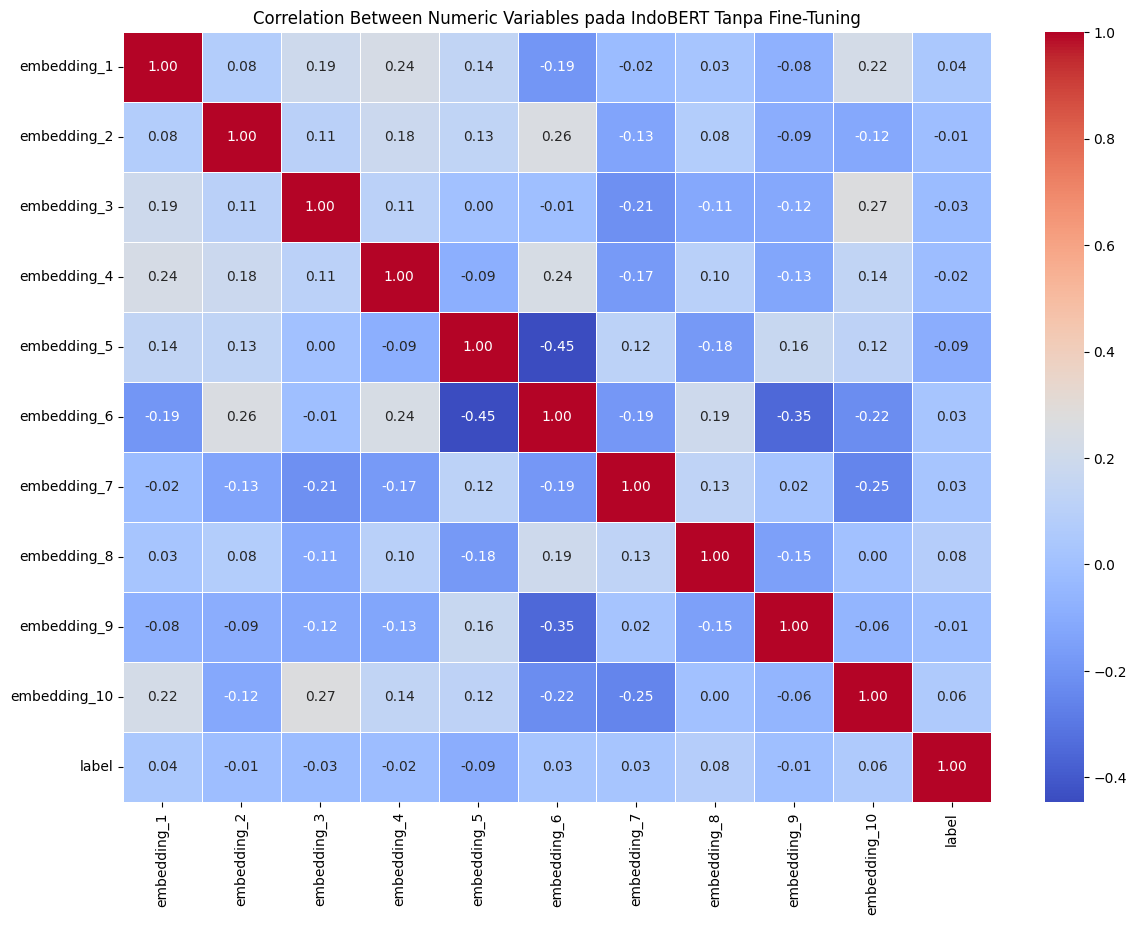

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
jumlah_dimensi = 10

embedding_df = pd.DataFrame(
    X_train[:, :jumlah_dimensi],
    columns=[f"embedding_{i+1}" for i in range(jumlah_dimensi)]
)

# Tambahkan label sebagai variabel numerik
embedding_df["label"] = y_train

# Hitung korelasi
correlation_matrix = embedding_df.corr()

# Tampilkan correlation matrix
display(correlation_matrix)

# Visualisasi heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Numeric Variables pada IndoBERT Tanpa Fine-Tuning")
plt.show()

##Train Logistic Regression sebagai classifier baseline

In [ ]:
baseline_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

baseline_clf.fit(X_train, y_train)

print("Classifier baseline selesai dilatih.")

Classifier baseline selesai dilatih.


##Evaluasi Validasi

In [ ]:
y_val_pred = baseline_clf.predict(X_val)

print("Validation Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["tidak_burnout", "burnout"],
        zero_division=0
    )
)

Validation Classification Report:
               precision    recall  f1-score   support

tidak_burnout       0.62      0.66      0.64        47
      burnout       0.77      0.74      0.76        74

     accuracy                           0.71       121
    macro avg       0.70      0.70      0.70       121
 weighted avg       0.71      0.71      0.71       121



In [ ]:
y_test_pred = baseline_clf.predict(X_test)

print("Test Classification Report Baseline IndoBERT Tanpa Fine-tuning:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["tidak_burnout", "burnout"],
        zero_division=0
    )
)

Test Classification Report Baseline IndoBERT Tanpa Fine-tuning:
               precision    recall  f1-score   support

tidak_burnout       0.64      0.67      0.65        48
      burnout       0.78      0.76      0.77        74

     accuracy                           0.72       122
    macro avg       0.71      0.71      0.71       122
 weighted avg       0.72      0.72      0.72       122



## Confusion Matrix

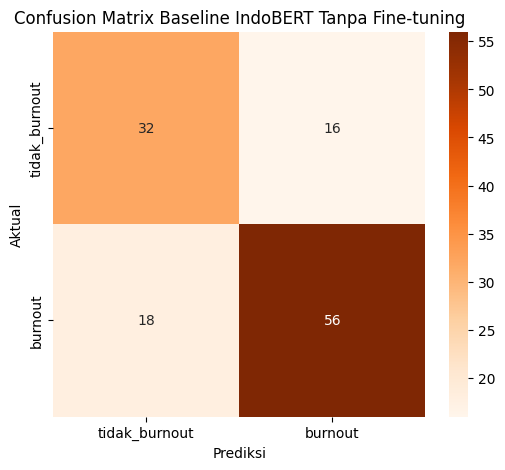

In [ ]:
cm_base = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["tidak_burnout", "burnout"],
    yticklabels=["tidak_burnout", "burnout"]
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Baseline IndoBERT Tanpa Fine-tuning")
plt.show()

##Simpan metrik baseline

In [ ]:
accuracy_base = accuracy_score(y_test, y_test_pred)

precision_base, recall_base, f1_base, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average="weighted",
    zero_division=0
)

hasil_baseline = pd.DataFrame([
    {
        "model": "IndoBERT tanpa fine-tuning + Logistic Regression",
        "accuracy": accuracy_base,
        "precision_weighted": precision_base,
        "recall_weighted": recall_base,
        "f1_weighted": f1_base
    }
])

display(hasil_baseline)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,IndoBERT tanpa fine-tuning + Logistic Regression,0.721311,0.72357,0.721311,0.722246


##Perbandingan

In [ ]:
hasil_finetuned = pd.DataFrame([
    {
        "model": "Fine-tuned IndoBERT",
        "accuracy": 0.7950,
        "precision_weighted": 0.8040,
        "recall_weighted": 0.7950,
        "f1_weighted": 0.7969
    }
])

perbandingan = pd.concat([hasil_baseline, hasil_finetuned], ignore_index=True)

display(perbandingan)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,IndoBERT tanpa fine-tuning + Logistic Regression,0.721311,0.72357,0.721311,0.722246
1,Fine-tuned IndoBERT,0.795000,0.80400,0.795000,0.796900


##Csv Perbandingan Model

In [ ]:
perbandingan.to_csv("perbandingan_model.csv", index=False, encoding="utf-8-sig")

from google.colab import files
files.download("perbandingan_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

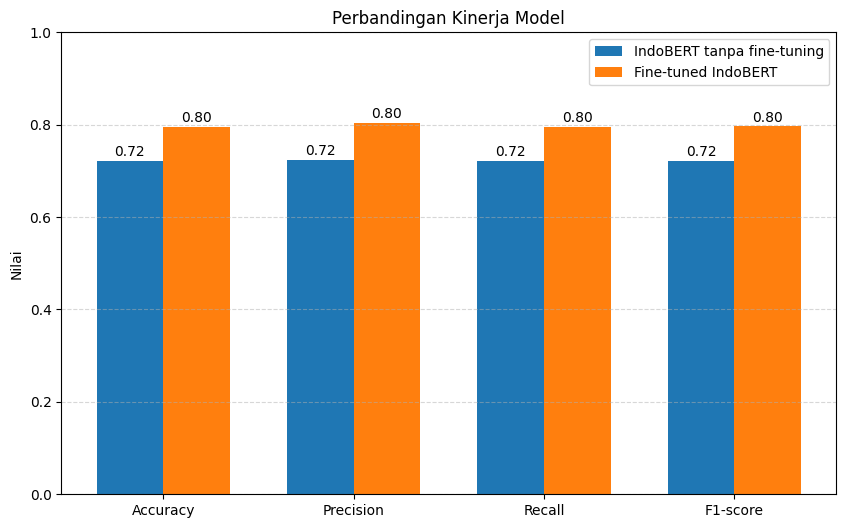

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]

baseline_values = perbandingan.loc[
    perbandingan["model"].str.contains("tanpa fine-tuning"),
    metrics
].values.flatten()

finetuned_values = perbandingan.loc[
    perbandingan["model"].str.contains("Fine-tuned"),
    metrics
].values.flatten()

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, baseline_values, width, label="IndoBERT tanpa fine-tuning")
plt.bar(x + width/2, finetuned_values, width, label="Fine-tuned IndoBERT")

plt.xticks(x, ["Accuracy", "Precision", "Recall", "F1-score"])
plt.ylim(0, 1)
plt.ylabel("Nilai")
plt.title("Perbandingan Kinerja Model")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(baseline_values):
    plt.text(i - width/2, v + 0.01, f"{v:.2f}", ha="center")

for i, v in enumerate(finetuned_values):
    plt.text(i + width/2, v + 0.01, f"{v:.2f}", ha="center")

plt.show()

In [ ]:
baseline = perbandingan.iloc[0]
finetuned = perbandingan.iloc[1]

peningkatan = pd.DataFrame([
    {
        "metrik": "Accuracy",
        "baseline": baseline["accuracy"],
        "fine_tuned": finetuned["accuracy"],
        "peningkatan": finetuned["accuracy"] - baseline["accuracy"]
    },
    {
        "metrik": "Precision",
        "baseline": baseline["precision_weighted"],
        "fine_tuned": finetuned["precision_weighted"],
        "peningkatan": finetuned["precision_weighted"] - baseline["precision_weighted"]
    },
    {
        "metrik": "Recall",
        "baseline": baseline["recall_weighted"],
        "fine_tuned": finetuned["recall_weighted"],
        "peningkatan": finetuned["recall_weighted"] - baseline["recall_weighted"]
    },
    {
        "metrik": "F1-score",
        "baseline": baseline["f1_weighted"],
        "fine_tuned": finetuned["f1_weighted"],
        "peningkatan": finetuned["f1_weighted"] - baseline["f1_weighted"]
    }
])

display(peningkatan)

peningkatan.to_csv("peningkatan_model.csv", index=False, encoding="utf-8-sig")
files.download("peningkatan_model.csv")

,metrik,baseline,fine_tuned,peningkatan
0,Accuracy,0.721311,0.7950,0.073689
1,Precision,0.723570,0.8040,0.080430
2,Recall,0.721311,0.7950,0.073689
3,F1-score,0.722246,0.7969,0.074654


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>